# TP : Raytracin
### Name: Arafat ISLAM
### Course: IG3D

# Color, Rays, Vectors

In [8]:
# I am defining a very small EPS value 
# because Later I will use this to avoid self intersection problem.
EPS = 1e-6

### I am writing my own clamp function because I want color values to stay between 0 and 1.

In [9]:
def clamp(x, a, b):
    # to check if x is below a then I return a.
    if x < a:
        return a
    # to check if x is above b then I return b.
    if x > b:
        return b
    # Otherwise x is inside [a,b] so I return x.
    return x

### I am writing my own sqrt using Newton method because teacher told us not to use built in libraries

In [10]:
def sqrt_newton(x):
    # If x is negative or zero sqrt is 0 for my raytracer usage.
    if x <= 0.0:
        return 0.0
    # starting with a guess g = x.
    g = x
    # I do a fixed number of iterations so it always finishes.
    i = 0
    while i < 20:
        # Newton updateis g = (g + x/g)/2
        g = 0.5 * (g + x / g)
        i += 1
    # now return the approximate sqrt.
    return g

###  vector class

In [11]:
# I am creating a Vector class in 3D because rays and normals are vectors.
class Vec3:
    # I store x,y,z values.
    def __init__(self, x=0.0, y=0.0, z=0.0):
        self.x = float(x)  # I convert to float to avoid integer issues.
        self.y = float(y)
        self.z = float(z)

    # I define addition because I will add points and vectors a lot.
    def add(self, other):
        return Vec3(self.x + other.x, self.y + other.y, self.z + other.z)

    # I define subtraction because I will compute directions like (P - C).
    def sub(self, other):
        return Vec3(self.x - other.x, self.y - other.y, self.z - other.z)

    # I define scalar multiply because I will do direction * t in rays.
    def mul(self, k):
        return Vec3(self.x * k, self.y * k, self.z * k)

    # I define dot product for lighting and intersection formulas.
    def dot(self, other):
        return self.x * other.x + self.y * other.y + self.z * other.z

    # I define cross product because camera basis vectors need it.
    def cross(self, other):
        return Vec3(
            self.y * other.z - self.z * other.y,
            self.z * other.x - self.x * other.z,
            self.x * other.y - self.y * other.x
        )

    # I define length so I can normalize vectors.
    def length(self):
        return sqrt_newton(self.dot(self))

    # I define normalize so directions and normals are unit vectors.
    def normalized(self):
        l = self.length()
        if l < EPS:
            return Vec3(0.0, 0.0, 0.0)
        return self.mul(1.0 / l)

    # I define a string display because in the lab manual its instructed display helpers for debugging.
    def show(self):
        return "Vec3(" + str(self.x) + ", " + str(self.y) + ", " + str(self.z) + ")"



### color class

In [12]:
# I am creating a Color class because pixels store colors (r,g,b).

class Color:
    def __init__(self, r=0.0, g=0.0, b=0.0):
        # I store values in range of [0,1].
        self.r = float(r)  
        self.g = float(g)
        self.b = float(b)

    # I add colors for summing light contributions.
    def add(self, other):
        return Color(self.r + other.r, self.g + other.g, self.b + other.b)

    # I multiply color by scalar for brightness and by color for component wise.
    def mul(self, k):
        if isinstance(k, Color):
            return Color(self.r * k.r, self.g * k.g, self.b * k.b)
        return Color(self.r * k, self.g * k, self.b * k)

    # I clamp the color because ppm must be in a valid range.
    def clamp01(self):
        return Color(clamp(self.r, 0.0, 1.0), clamp(self.g, 0.0, 1.0), clamp(self.b, 0.0, 1.0))

    # I convert to 0 to 255 integers for PPM output.
    def to_255(self):
        c = self.clamp01()
        return (int(c.r * 255.0 + 0.5), int(c.g * 255.0 + 0.5), int(c.b * 255.0 + 0.5))

    # I also create a debug display.
    def show(self):
        return "Color(" + str(self.r) + ", " + str(self.g) + ", " + str(self.b) + ")"



### ray class

In [13]:
# I create a Ray class because raycasting uses rays.
class Ray:
    def __init__(self, origin, direction):
        # I want to store the ray start point.
        self.origin = origin  
         # I need to normalize direction for stable math.
        self.direction = direction.normalized() 

    # I compute a point along the ray to origin + t * direction.
    def at(self, t):
        return self.origin.add(self.direction.mul(t))



### Define a function to visualize the ppm image

In [14]:

import matplotlib.pyplot as plt

# I have defined this function to visualize the image that in ppm format.
def read_ppm_p3(path):
    with open(path, "r") as f:
        # Read tokens, ignoring comments
        tokens = []
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "#" in line:
                line = line.split("#", 1)[0].strip()
            tokens.extend(line.split())

    if tokens[0] != "P3":
        raise ValueError("Not a P3 PPM file")

    w = int(tokens[1])
    h = int(tokens[2])
    maxv = int(tokens[3])

    data = list(map(int, tokens[4:]))

    # Normalize to 0 and 1 for display
    img = []
    i = 0
    y = 0
    while y < h:
        row = []
        x = 0
        while x < w:
            r = data[i] / maxv; g = data[i+1] / maxv; b = data[i+2] / maxv
            row.append([r, g, b])
            i += 3
            x += 1
        img.append(row)
        y += 1

    return img




### testting

In [15]:

# I have created two vectors and test add, sub, dot calculations
a = Vec3(1, 2, 3)
b = Vec3(10, 0, -2)
print("vector a =", a.show())
print("vector b =", b.show())
print("vector a+b =", a.add(b).show())
print("vector a-b =", a.sub(b).show())
print("vector a·b =", a.dot(b))

# I test ray at(t).
ray = Ray(Vec3(0, 0, 0), Vec3(0, 0, -1))
p = ray.at(5)
print("Ray at t=5 gives:", p.show())

# I test color conversion to ppm values.
col = Color(1.2, 0.4, -0.1)
print("Color clamp + to_255:", col.to_255())

vector a = Vec3(1.0, 2.0, 3.0)
vector b = Vec3(10.0, 0.0, -2.0)
vector a+b = Vec3(11.0, 2.0, 1.0)
vector a-b = Vec3(-9.0, 2.0, 5.0)
vector a·b = 4.0
Ray at t=5 gives: Vec3(0.0, 0.0, -5.0)
Color clamp + to_255: (255, 102, 0)


### Image class and PPM saving in 2D pixels

In [16]:
# I am implementing Image as a 2D array pixels[y][x] 
class Image:
    def __init__(self, width, height):
        # I store width and height
        self.width = int(width)    
        self.height = int(height)  

        # I create the 2D pixel array.
        self.pixels = []
        y = 0
        while y < self.height:
            # I have started with creating one row.
            row = []  
            x = 0
            while x < self.width:
                # I start with black pixels.
                row.append(Color(0.0, 0.0, 0.0))  
                x += 1
            
            # I add the row to the image.
            self.pixels.append(row)  
            y += 1

    # I set one pixel.
    def set_pixel(self, x, y, c):
        self.pixels[y][x] = c

    # I convert my image to PPM 
    def to_ppm_string(self):
        # I write ppm header.
        header = "P3\n" + str(self.width) + " " + str(self.height) + "\n255\n"  
        # I build body as text.
        body = ""  

        y = 0
        while y < self.height:
            x = 0
            while x < self.width:
                # I convert to integers.
                r, g, b = self.pixels[y][x].to_255()  
                # I add pixel values.
                body += str(r) + " " + str(g) + " " + str(b) + " "  
                x += 1
            # I go to next row line.
            body += "\n" 
            y += 1

        return header + body

    # I save ppm to a file, because this needs for visualization.
    def save_ppm(self, filename):
        # I open file in write mode.
        f = open(filename, "w")          
        # I write the whole ppm content.
        f.write(self.to_ppm_string())    
        # I also need to close file.
        f.close()                        




### testing

P3
16 10
255
First pixel line example: ['P3', '16 10', '255', '0 0 51 17 0 51 34 0 51 51 0 51 68 0 51 85 0 51 102 0 51 119 0 51 136 0 51 153 0 51 170 0 51 187 0 51 204 0 51 221 0 51 238 0 51 255 0 51 ', '0 28 51 17 28 51 34 28 51 51 28 51 68 28 51 85 28 51 102 28 51 119 28 51 136 28 51 153 28 51 170 28 51 187 28 51 204 28 51 221 28 51 238 28 51 255 28 51 ', '0 57 51 17 57 51 34 57 51 51 57 51 68 57 51 85 57 51 102 57 51 119 57 51 136 57 51 153 57 51 170 57 51 187 57 51 204 57 51 221 57 51 238 57 51 255 57 51 ', '0 85 51 17 85 51 34 85 51 51 85 51 68 85 51 85 85 51 102 85 51 119 85 51 136 85 51 153 85 51 170 85 51 187 85 51 204 85 51 221 85 51 238 85 51 255 85 51 ', '0 113 51 17 113 51 34 113 51 51 113 51 68 113 51 85 113 51 102 113 51 119 113 51 136 113 51 153 113 51 170 113 51 187 113 51 204 113 51 221 113 51 238 113 51 255 113 51 ', '0 142 51 17 142 51 34 142 51 51 142 51 68 142 51 85 142 51 102 142 51 119 142 51 136 142 51 153 142 51 170 142 51 187 142 51 204 142 51 221 142 51 238 1

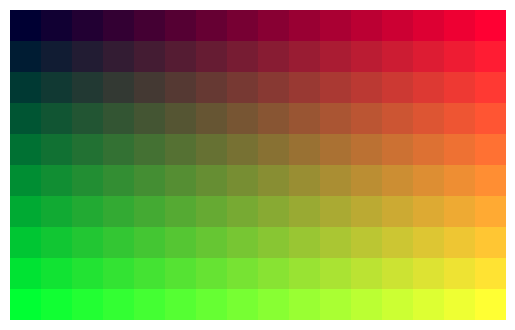

In [17]:
# making a small gradient image and save it

# I create a small image so it is fast.
img = Image(16, 10)  

# I fill with a gradient so I can see if ppm works.
y = 0
while y < img.height:
    x = 0
    while x < img.width:
        # I make red depend on x green depend on y and blue fixed.
        r = x / (img.width - 1)
        g = y / (img.height - 1)
        b = 0.2
        img.set_pixel(x, y, Color(r, g, b))
        x += 1
    y += 1
# I save so I can open it for visualization.
img.save_ppm("test_gradient.ppm")  

# I print first few lines to see the ppm text looks correct.
ppm_text = img.to_ppm_string().splitlines()
print(ppm_text[0])
print(ppm_text[1])
print(ppm_text[2])
print("First pixel line example:", ppm_text)


img = read_ppm_p3("test_gradient.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()

### now I need to implement the Scene Part
### Texture_Material and Uniform_Texture 

In [19]:
# I create an abstract class TextureMaterial as instructed in the lab manual
'''
from the lab manual: an abstract class for Texture_Material with (at least) one pure virtual method which provide
all parameters for the texture and the material (kd, ks...). 
'''

class TextureMaterial:
    # I define sample means point that returns kd, ks, etc
    # but here I am using subclasses to do this.
    def sample(self, point):
        raise Exception("no sample ()")

# I create UniformTexture which will returns the same values everywhere.
class UniformTexture(TextureMaterial):
    def __init__(self, kd, ks, shininess, reflectivity=0.0, ambient=0.0):
        # first I need to store diffuse color.
        self.kd = kd    
        # now I need to store specular color.
        self.ks = ks            
        # I also need to store specular exponent.
        self.shininess = int(shininess)  
        # to control I need store reflection amount in range 0 to 1.
        self.reflectivity = float(reflectivity)  
        # also I need to store ambient strength.
        self.ambient = float(ambient)         

    def sample(self, point):
        # I return a dictionary of parameters like kd, ks, shininess etc.
        return {
            "kd": self.kd,
            "ks": self.ks,
            "shininess": self.shininess,
            "reflectivity": self.reflectivity,
            "ambient": self.ambient
        }


### testing the class

In [56]:

materials = UniformTexture(kd=Color(1, 0, 0), ks=Color(1, 1, 1), shininess=50, reflectivity=0.2, ambient=0.05)
print("materials: ", materials)
params = materials.sample(Vec3(0, 0, 0))
print("kd =", params["kd"].show())
print("ks =", params["ks"].show())
print("shininess =", params["shininess"])
print("reflectivity =", params["reflectivity"])
print("ambient =", params["ambient"])

materials:  <__main__.UniformTexture object at 0x000001C337AD3C20>
kd = Color(1.0, 0.0, 0.0)
ks = Color(1.0, 1.0, 1.0)
shininess = 50
reflectivity = 0.2
ambient = 0.05


# now I have implemented the Scene Part it has Object abstract and Sphere and intersection, normal, texture 

In [23]:
# I create an abstract Object3D class following the lab manual.
class Object3D:
    def __init__(self, texture_material):
        # I need to store the material.
        self.texture_material = texture_material  

    # now I need to return hit information or None.
    def intersect(self, ray):
        raise Exception("no intersect at this point")

    # need a function to return normal vector at surface point.
    def normal_at(self, point):
        raise Exception("no normal vector at this point")

    # this function to returns the material parameters at a point like delegates to TextureMaterial.
    def material_at(self, point):
        return self.texture_material.sample(point)

### Now I create a Hit class to store intersection results in a simple way.

In [25]:
class Hit:
    def __init__(self, t, point, normal, material, obj):
        self.t = t
        self.point = point
        self.normal = normal
        self.material = material
        self.obj = obj

### now i need to implement Sphere shape object.

In [26]:

class Sphere(Object3D):
    def __init__(self, center, radius, texture_material):
        # I call parent constructor.
        Object3D.__init__(self, texture_material)  
        # I store center.
        self.center = center     
        # I store radius.
        self.radius = float(radius)                 

    # I compute intersection using the quadratic equation.
    def intersect(self, ray):
        # vector from sphere center to ray origin.
        oc = ray.origin.sub(self.center)  

        # usually 1 if normalized.
        a = ray.direction.dot(ray.direction)   
        # 2 * oc·d
        b = 2.0 * oc.dot(ray.direction)    
        # oc·oc - r^2
        c = oc.dot(oc) - self.radius * self.radius       

        # discriminant
        disc = b * b - 4.0 * a * c  
        if disc < 0.0:
            # no hit
            return None  

        # sqrt discriminant
        s = sqrt_newton(disc)   
        # I precompute 1/(2a)
        inv2a = 1.0 / (2.0 * a)    

        # near solution
        t0 = (-b - s) * inv2a 
        # far solution
        t1 = (-b + s) * inv2a      

        # I choose the smallest positive t.
        t = None
        if t0 > EPS and t1 > EPS:
            t = t0 if t0 < t1 else t1
        elif t0 > EPS:
            t = t0
        elif t1 > EPS:
            t = t1

        if t is None:
            return None

        # I compute point and normal.
        p = ray.at(t)
        n = self.normal_at(p)
        m = self.material_at(p)

        return Hit(t, p, n, m, self)

    # Normal on a sphere is (p - center) normalized.
    def normal_at(self, point):
        return point.sub(self.center).normalized()

### now testing intersect a ray with a sphere

In [27]:
sphere_mat = UniformTexture(kd=Color(0, 1, 0), ks=Color(1, 1, 1), shininess=30)
s = Sphere(center=Vec3(0, 0, -5), radius=1.0, texture_material=sphere_mat)

test_ray = Ray(origin=Vec3(0, 0, 0), direction=Vec3(0, 0, -1))
hit = s.intersect(test_ray)

if hit is None:
    print("No intersection")
else:
    print("Hit t =", hit.t)
    print("Hit point =", hit.point.show())
    print("Hit normal =", hit.normal.show())
    print("Hit kd =", hit.material["kd"].show())

Hit t = 4.0
Hit point = Vec3(0.0, 0.0, -4.0)
Hit normal = Vec3(0.0, 0.0, 1.0)
Hit kd = Color(0.0, 1.0, 0.0)


### now Scene Part of Light abstract and Point Light

In [28]:
# I define an abstract Light class.
class Light:
    def sample(self, point):
        raise Exception("nothing yet.")


### Now I have implemented the PointLight as described in the lab manual.

In [30]:

class PointLight(Light):
    def __init__(self, position, color, intensity=1.0):
        # I need to store position.
        self.position = position  
        # I need to store light color.
        self.color = color       
        # I need to store intensity.
        self.intensity = float(intensity)  

    # I return direction to light, distance and radiance.
    def sample(self, point):
        # vector from point to light
        v = self.position.sub(point)  
        # distance to light
        dist = v.length()              
        if dist < EPS:
            return None
        # normalizing direction
        dir_to_light = v.mul(1.0 / dist)  

        # I use simple attenuation 1/(dist^2) so far lights are weaker.
        att = 1.0 / (dist * dist)

        # so this is the final contribution
        radiance = self.color.mul(self.intensity * att)  
        return (dir_to_light, dist, radiance)



### testing sample point light

In [31]:
L = PointLight(position=Vec3(0, 5, 0), color=Color(1, 1, 1), intensity=20.0)
sample = L.sample(Vec3(0, 0, 0))
print("Light sample =", sample[0].show(), "dist =", sample[1], "radiance =", sample[2].show())

Light sample = Vec3(0.0, 1.0, 0.0) dist = 5.0 radiance = Color(0.8, 0.8, 0.8)


### Now camera part Camera (C, P, up, α, β, zmin)

In [32]:
class Camera:
    def __init__(self, C, P, up, alpha, beta, zmin):
        # camera position
        self.C = C     
        # target point
        self.P = P   
        # up direction
        self.up = up.normalized()    

        # width of view plane
        self.alpha = float(alpha)  
        # height of view plane
        self.beta = float(beta)   
        # distance to image plane
        self.zmin = float(zmin)      

        # I compute camera basis vectors.
        # this is for forward direction
        self.forward = self.P.sub(self.C).normalized() 
        # for right direction
        self.right = self.forward.cross(self.up).normalized()  
        # for corrected up direction
        self.true_up = self.right.cross(self.forward).normalized()

    # now I need to generate a ray for pixel (x,y).
    def ray_for_pixel(self, x, y, width, height):
        # I compute image plane center.
        center = self.C.add(self.forward.mul(self.zmin))

        # I map pixel coordinate into [-1,1] for both axes.
        u = ((x + 0.5) / width) * 2.0 - 1.0
        v = 1.0 - ((y + 0.5) / height) * 2.0

        # now need to compute pixel position in 3D.
        pixel_pos = center.add(self.right.mul(u * self.alpha)).add(self.true_up.mul(v * self.beta))

        # finally returning a ray from camera center through that pixel.
        return Ray(self.C, pixel_pos.sub(self.C))


### testing camera center pixel ray

In [35]:
cam = Camera(C=Vec3(0, 0, 0), P=Vec3(0, 0, -1), up=Vec3(0, 1, 0), alpha=1.0, beta=1.0, zmin=1.0)
r_center = cam.ray_for_pixel(50, 50, 100, 100)
print("Center ray origin =", r_center.origin.show())
print("Center ray dir =", r_center.direction.show())

Center ray origin = Vec3(0.0, 0.0, 0.0)
Center ray dir = Vec3(0.009999000149975014, -0.009999000149975014, -0.9999000149975006)


### now the Scene container class with objects + lights + camera

In [37]:
class Scene:
    def __init__(self):
        # I store all objects here.
        self.objects = []   
        # I have to store all lights here.
        self.lights = []   
        # I need to store the camera here.
        self.camera = None    
        # background color
        self.bg = Color(0, 0, 0) 

    def add_object(self, obj):
        self.objects.append(obj)

    def add_light(self, light):
        self.lights.append(light)

    def set_camera(self, cam):
        self.camera = cam

    # I have to compute to find the nearest intersection.
    def intersect(self, ray):
        nearest = None
        i = 0
        while i < len(self.objects):
            hit = self.objects[i].intersect(ray)
            if hit is not None:
                if nearest is None or hit.t < nearest.t:
                    nearest = hit
            i += 1
        return nearest



### testing scene with one sphere and cast one ray

In [38]:
scene = Scene()
scene.set_camera(Camera(Vec3(0,0,0), Vec3(0,0,-1), Vec3(0,1,0), 1, 1, 1))
scene.add_object(Sphere(Vec3(0,0,-5), 1.0, UniformTexture(Color(1,0,0), Color(1,1,1), 20)))
ray = scene.camera.ray_for_pixel(50, 50, 100, 100)
hit = scene.intersect(ray)
if hit is not None:
    print("Hit color kd =", hit.material["kd"].show())

Hit color kd = Color(1.0, 0.0, 0.0)


### this is the implementation of Engine part

### Engine step for visible points only
### here I have created a simple renderer class so I can add other steps later step by step.

In [42]:
class Renderer:
    def __init__(self):
        # I set reflection recursion limit later.
        self.max_depth = 5  

    # this is to just return object base color if hit.
    def shade_step1(self, scene, ray):
        hit = scene.intersect(ray)
        if hit is None:
            return scene.bg
        # I return object color without lighting.
        return hit.material["kd"]  

    # This render function runs shading for each pixel.
    def render_step1(self, scene, width, height):
        img = Image(width, height)

        y = 0
        while y < height:
            x = 0
            while x < width:
                r = scene.camera.ray_for_pixel(x, y, width, height)
                c = self.shade_step1(scene, r)
                img.set_pixel(x, y, c)
                x += 1
            y += 1

        return img



    
    # I have added a new render function with anti-aliasing 
    # because one ray per pixel makes jagged and not smooth edges on curves.
    
    def render_step6_antialias(self, scene, width, height, samples):
        # I create the output image as before.
        img = Image(width, height)
    
        # I need to loop over pixels.
        y = 0
        while y < height:
            x = 0
            while x < width:
    
                # I start with black because I will add many samples then average.
                total = Color(0, 0, 0)
    
                # I shoot a grid of rays inside the pixel.
                # For example samples=2 it's 2x2 = 4 rays.
                # thsi helps me in smoothing the rendered image
                sy = 0
                while sy < samples:
                    sx = 0
                    while sx < samples:
    
                        # I compute a small offset inside the pixel like sub pixels.
                        # I do sx+0.5/samples so it hits the center of each sub cell.
                        ox = (sx + 0.5) / samples
                        oy = (sy + 0.5) / samples
    
                        # I create a ray for that subpixel.
                        # I copy the camera logic but I add ox, oy into x,y.
                        center = scene.camera.C.add(scene.camera.forward.mul(scene.camera.zmin))
    
                        u = (((x + ox) / width) * 2.0) - 1.0
                        v = 1.0 - (((y + oy) / height) * 2.0)
    
                        pixel_pos = center.add(scene.camera.right.mul(u * scene.camera.alpha)).add(
                            scene.camera.true_up.mul(v * scene.camera.beta)
                        )
    
                        r = Ray(scene.camera.C, pixel_pos.sub(scene.camera.C))
    
                        # I shade using shadows, reflection  and ambient.
                        c = self.shade_step6(scene, r, 0)
    
                        # I add the color to total.
                        total = total.add(c)
    
                        sx += 1
                    sy += 1
    
                # I average the samples so pixel color is mean value.
                scale = 1.0 / (samples * samples)
                avg = total.mul(scale)
    
                # I write averaged color into image.
                img.set_pixel(x, y, avg)
    
                x += 1
            y += 1
    
        return img

### Testing the scene for only object color without lighting.

In [43]:
scene1 = Scene()
scene1.bg = Color(0.1, 0.1, 0.15)
scene1.set_camera(Camera(Vec3(0,0.5,3), Vec3(0,0.3,0), Vec3(0,1,0), 1.2, 0.9, 1.0))

red_mat = UniformTexture(Color(1,0,0), Color(1,1,1), 40)
blue_mat = UniformTexture(Color(0.2,0.2,1), Color(1,1,1), 40)
scene1.add_object(Sphere(Vec3(-0.8,0.4,0), 0.4, red_mat))
scene1.add_object(Sphere(Vec3(0.6,0.35,-0.6), 0.35, blue_mat))

renderer = Renderer()
img1 = renderer.render_step1(scene1, 200, 150)
img1.save_ppm("object_color_without_lighting.ppm")
print("I have saved the object_color_without_lighting.ppm")

I have saved the object_color_without_lighting.ppm


### visualizing the object_color_without_lighting.ppm image.

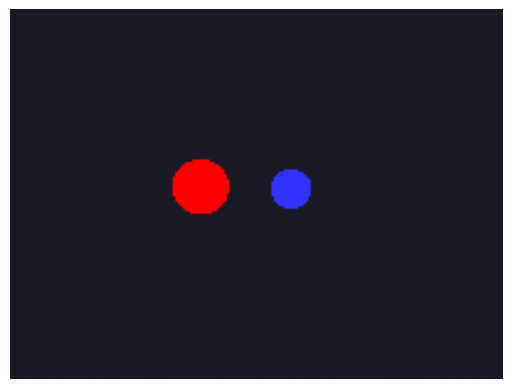

In [44]:
img = read_ppm_p3("object_color_without_lighting.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()

### here I have imlemented the Engine part of  diffuse lighting 

In [45]:
# I have updated renderer class 
# now I compute diffuse light = kd * max(0, N·L) for each light.
class Renderer:
    def __init__(self):
        self.max_depth = 5

    def shade_step2(self, scene, ray):
        hit = scene.intersect(ray)
        if hit is None:
            return scene.bg

        p = hit.point
        n = hit.normal
        m = hit.material

        # diffuse base color
        kd = m["kd"]  

        # I start with black then I add diffuse contributions.
        out = Color(0,0,0)

        li = 0
        while li < len(scene.lights):
            sample = scene.lights[li].sample(p)
            if sample is not None:
                l_dir, l_dist, radiance = sample

                ndotl = n.dot(l_dir)
                if ndotl > 0.0:
                    # diffuse = kd * ndotl * radiance
                    out = out.add(kd.mul(ndotl).mul(radiance))

            li += 1

        return out

    def render_step2(self, scene, width, height):
        img = Image(width, height)

        y = 0
        while y < height:
            x = 0
            while x < width:
                r = scene.camera.ray_for_pixel(x, y, width, height)
                c = self.shade_step2(scene, r)
                img.set_pixel(x, y, c)
                x += 1
            y += 1

        return img


### Testing the scene with diffuse lights

In [47]:
# I reuse the same scene setup.
scene2 = scene1 
# I clear lights then add new ones.
scene2.lights = []  
scene2.add_light(PointLight(Vec3(2,3,2), Color(1,1,1), intensity=25))
scene2.add_light(PointLight(Vec3(-2,2,2), Color(1,0.9,0.8), intensity=15))

renderer = Renderer()
img2 = renderer.render_step2(scene2, 200, 150)
img2.save_ppm("scene_with_diffuse_lights.ppm")
print("saved the scene_with_diffuse_lights.ppm")

saved the scene_with_diffuse_lights.ppm


### visualizing scene_with_diffuse_lights.ppm

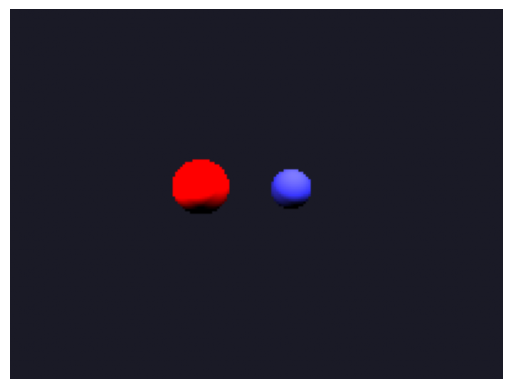

In [48]:
img = read_ppm_p3("scene_with_diffuse_lights.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()

### now implementing Engine part of Specular lighting

In [50]:
# I need to implement integer power as teacher told me not to use built-in libraries 
def pow_int(x, n):
    if n <= 0:
        return 1.0
    r = 1.0
    i = 0
    while i < n:
        r *= x
        i += 1
    return r

# I again updating renderer class for specular using reflection vector.
class Renderer:
    def __init__(self):
        self.max_depth = 5

    # I compute reflection direction: R = I - 2(I·N)N
    def reflect(self, I, N):
        return I.sub(N.mul(2.0 * I.dot(N)))

    def shade_step3(self, scene, ray):
        hit = scene.intersect(ray)
        if hit is None:
            return scene.bg

        p = hit.point
        n = hit.normal
        m = hit.material

        kd = m["kd"]
        ks = m["ks"]
        s = m["shininess"]

        # I compute view direction (toward camera).
        v = ray.origin.sub(p).normalized()

        out = Color(0,0,0)

        li = 0
        while li < len(scene.lights):
            sample = scene.lights[li].sample(p)
            if sample is not None:
                l_dir, l_dist, radiance = sample

                # Diffuse
                ndotl = n.dot(l_dir)
                if ndotl > 0.0:
                    out = out.add(kd.mul(ndotl).mul(radiance))

                # Specular
                # I use I = -L (incoming direction to surface).
                I = l_dir.mul(-1.0)
                r = self.reflect(I, n).normalized()
                rdotv = r.dot(v)

                if rdotv > 0.0:
                    spec = pow_int(rdotv, s)
                    out = out.add(ks.mul(spec).mul(radiance))

            li += 1

        return out

    def render_step3(self, scene, width, height):
        img = Image(width, height)

        y = 0
        while y < height:
            x = 0
            while x < width:
                r = scene.camera.ray_for_pixel(x, y, width, height)
                c = self.shade_step3(scene, r)
                img.set_pixel(x, y, c)
                x += 1
            y += 1

        return img


### testing scene with specular lighting

In [51]:
renderer = Renderer()
img3 = renderer.render_step3(scene2, 200, 150)
img3.save_ppm("scene_with_specular_lighting.ppm")
print("saved scene_with_specular_lighting.ppm")

saved scene_with_specular_lighting.ppm


### visualizing the scene_with_specular_lighting.ppm

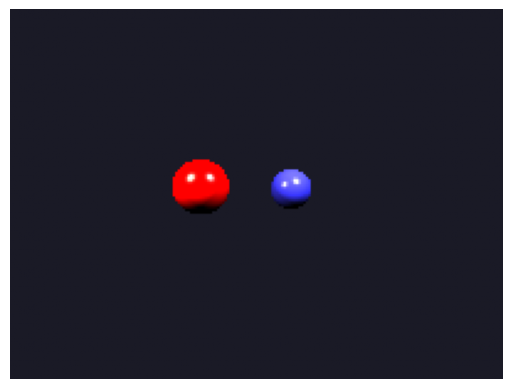

In [52]:
img = read_ppm_p3("scene_with_specular_lighting.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()

### now implementing Engine part for ambient light

In [53]:
# I again updatethe  renderer class 
# I add ambient term = kd * ambient_strength
class Renderer:
    def __init__(self):
        self.max_depth = 5

    def reflect(self, I, N):
        return I.sub(N.mul(2.0 * I.dot(N)))

    def shade_step4(self, scene, ray):
        hit = scene.intersect(ray)
        if hit is None:
            return scene.bg

        p = hit.point
        n = hit.normal
        m = hit.material

        kd = m["kd"]
        ks = m["ks"]
        s = m["shininess"]
        ambient_strength = m.get("ambient", 0.05)

        v = ray.origin.sub(p).normalized()

        # I start with ambient instead of black now.
        out = kd.mul(ambient_strength)

        li = 0
        while li < len(scene.lights):
            sample = scene.lights[li].sample(p)
            if sample is not None:
                l_dir, l_dist, radiance = sample

                ndotl = n.dot(l_dir)
                if ndotl > 0.0:
                    out = out.add(kd.mul(ndotl).mul(radiance))

                I = l_dir.mul(-1.0)
                r = self.reflect(I, n).normalized()
                rdotv = r.dot(v)
                if rdotv > 0.0:
                    spec = pow_int(rdotv, s)
                    out = out.add(ks.mul(spec).mul(radiance))

            li += 1

        return out

    def render_step4(self, scene, width, height):
        img = Image(width, height)

        y = 0
        while y < height:
            x = 0
            while x < width:
                r = scene.camera.ray_for_pixel(x, y, width, height)
                c = self.shade_step4(scene, r)
                img.set_pixel(x, y, c)
                x += 1
            y += 1

        return img


### testing and visualizing scene with ambient light

saved scene_with_ambient_light.ppm


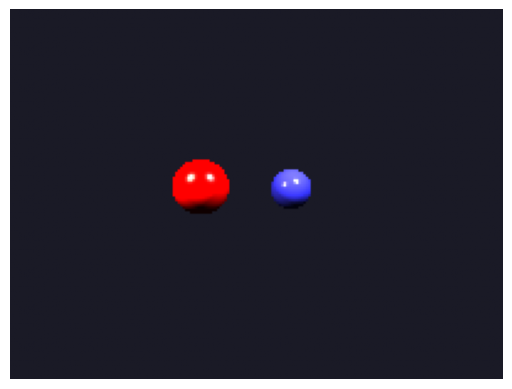

In [54]:
# I give my materials some ambient so the shadows won't be pure black later.
red_mat = UniformTexture(Color(1,0,0), Color(1,1,1), 40, reflectivity=0.0, ambient=0.06)
blue_mat = UniformTexture(Color(0.2,0.2,1), Color(1,1,1), 60, reflectivity=0.0, ambient=0.06)

scene2.objects = []
scene2.add_object(Sphere(Vec3(-0.8,0.4,0), 0.4, red_mat))
scene2.add_object(Sphere(Vec3(0.6,0.35,-0.6), 0.35, blue_mat))

renderer = Renderer()
img4 = renderer.render_step4(scene2, 200, 150)
img4.save_ppm("scene_with_ambient_light.ppm")
print("saved scene_with_ambient_light.ppm")
# visualizing
img = read_ppm_p3("scene_with_ambient_light.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()

### I have implemented Engine for Reflection (in recursive)

In [56]:
# I update renderer class 
# I add reflection rays recursively with a max depth.
class Renderer:
    def __init__(self, max_depth=5):
        self.max_depth = int(max_depth)
        # I use a small bias so reflection ray starts above the surface.
        self.bias = 1e-4 

    def reflect(self, I, N):
        return I.sub(N.mul(2.0 * I.dot(N)))

    def shade_step5(self, scene, ray, depth):
        hit = scene.intersect(ray)
        if hit is None:
            return scene.bg

        p = hit.point
        n = hit.normal
        m = hit.material

        kd = m["kd"]
        ks = m["ks"]
        s = m["shininess"]
        ambient_strength = m.get("ambient", 0.05)
        refl = m.get("reflectivity", 0.0)

        v = ray.origin.sub(p).normalized()

        out = kd.mul(ambient_strength)

        li = 0
        while li < len(scene.lights):
            sample = scene.lights[li].sample(p)
            if sample is not None:
                l_dir, l_dist, radiance = sample

                ndotl = n.dot(l_dir)
                if ndotl > 0.0:
                    out = out.add(kd.mul(ndotl).mul(radiance))

                I = l_dir.mul(-1.0)
                r = self.reflect(I, n).normalized()
                rdotv = r.dot(v)
                if rdotv > 0.0:
                    spec = pow_int(rdotv, s)
                    out = out.add(ks.mul(spec).mul(radiance))

            li += 1

        # Reflection part 
        if refl > 0.0 and depth < self.max_depth:
            # I compute reflected direction from the incoming ray direction.
            rdir = self.reflect(ray.direction, n).normalized()

            # I offset the origin a bit so it doesn't immediately re-hit the same surface.
            rorig = p.add(rdir.mul(self.bias))

            # I compute reflection color recursively.
            rc = self.shade_step5(scene, Ray(rorig, rdir), depth + 1)

            # I mix base shading and reflection.
            out = out.mul(1.0 - refl).add(rc.mul(refl))

        return out

    def render_step5(self, scene, width, height):
        img = Image(width, height)

        y = 0
        while y < height:
            x = 0
            while x < width:
                r = scene.camera.ray_for_pixel(x, y, width, height)
                c = self.shade_step5(scene, r, 0)
                img.set_pixel(x, y, c)
                x += 1
            y += 1

        return img

### testing and visualizing scene with reflection

saved scene_with_reflection


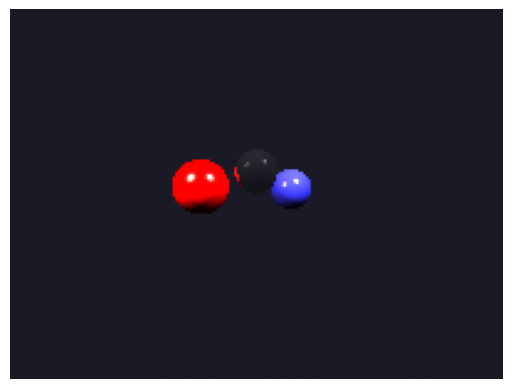

In [57]:
# I create one reflective sphere to see the effect.
mirror_mat = UniformTexture(Color(0.1,0.1,0.1), Color(1,1,1), 120, reflectivity=0.7, ambient=0.02)
scene2.add_object(Sphere(Vec3(0.0,0.6,0.6), 0.25, mirror_mat))

renderer = Renderer(max_depth=5)
img5 = renderer.render_step5(scene2, 200, 150)
img5.save_ppm("scene_with_reflection.ppm")
print("saved scene_with_reflection")
# visualizing
img = read_ppm_p3("scene_with_reflection.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()

### with anti alaising

In [63]:
# I am re writing the Renderer class again
# I want to try with and without anti alaising
# because I don't want to Jupyter notebook to overwrite the previous Renderer with this.

class Renderer:
    def __init__(self, max_depth=5):
        # I limit recursion for reflection
        self.max_depth = int(max_depth)  
        # I use a new rays a tiny bit forward to avoid self hit
        self.bias = 1e-4                  

    def reflect(self, I, N):
        # I compute reflection directionusing R = I - 2(I·N)N
        return I.sub(N.mul(2.0 * I.dot(N)))

    def in_shadow(self, scene, point, light_dir, light_dist):
        # I create a shadow ray starting slightly above the surface
        shadow_origin = point.add(light_dir.mul(self.bias))
        shadow_ray = Ray(shadow_origin, light_dir)

        hit = scene.intersect(shadow_ray)
        if hit is None:
            return False

        # If I hit something before the light distance then I'm in shadow
        return hit.t < (light_dist - self.bias)

    def shade_step6(self, scene, ray, depth):
        # I find the nearest object hit by the ray
        hit = scene.intersect(ray)
        if hit is None:
            return scene.bg

        # I extract intersection info
        p = hit.point
        n = hit.normal
        m = hit.material

        # I get material parameters
        kd = m["kd"]
        ks = m["ks"]
        s = m["shininess"]
        ambient_strength = m.get("ambient", 0.05)
        refl = m.get("reflectivity", 0.0)

        # I compute view direction toward camera
        v = ray.origin.sub(p).normalized()

        # I start with ambient color
        out = kd.mul(ambient_strength)

        # I loop over lights
        li = 0
        while li < len(scene.lights):
            sample = scene.lights[li].sample(p)
            if sample is not None:
                l_dir, l_dist, radiance = sample

                # I do shadow test
                if self.in_shadow(scene, p, l_dir, l_dist):
                    li += 1
                    continue

                # Diffuse part
                ndotl = n.dot(l_dir)
                if ndotl > 0.0:
                    out = out.add(kd.mul(ndotl).mul(radiance))

                # Specular part
                I = l_dir.mul(-1.0)
                r = self.reflect(I, n).normalized()
                rdotv = r.dot(v)
                if rdotv > 0.0:
                    spec = pow_int(rdotv, s)
                    out = out.add(ks.mul(spec).mul(radiance))

            li += 1

        # now the reflection part
        if refl > 0.0 and depth < self.max_depth:
            rdir = self.reflect(ray.direction, n).normalized()
            rorig = p.add(rdir.mul(self.bias))
            rc = self.shade_step6(scene, Ray(rorig, rdir), depth + 1)
            out = out.mul(1.0 - refl).add(rc.mul(refl))

        return out

    def render_step6(self, scene, width, height):
        # I render with 1 ray per pixel no anti-aliasing
        img = Image(width, height)

        y = 0
        while y < height:
            x = 0
            while x < width:
                r = scene.camera.ray_for_pixel(x, y, width, height)
                c = self.shade_step6(scene, r, 0)
                img.set_pixel(x, y, c)
                x += 1
            y += 1

        return img

    def render_step6_antialias(self, scene, width, height, samples):
        # I render with multiple rays per pixel to smooth edges
        img = Image(width, height)

        y = 0
        while y < height:
            x = 0
            while x < width:
                total = Color(0, 0, 0)

                sy = 0
                while sy < samples:
                    sx = 0
                    while sx < samples:
                        # I compute subpixel offsets
                        ox = (sx + 0.5) / samples
                        oy = (sy + 0.5) / samples

                        # I generate the ray like camera.ray_for_pixel but with offsets
                        center = scene.camera.C.add(scene.camera.forward.mul(scene.camera.zmin))

                        u = (((x + ox) / width) * 2.0) - 1.0
                        v = 1.0 - (((y + oy) / height) * 2.0)

                        pixel_pos = center.add(scene.camera.right.mul(u * scene.camera.alpha)).add(
                            scene.camera.true_up.mul(v * scene.camera.beta)
                        )

                        r = Ray(scene.camera.C, pixel_pos.sub(scene.camera.C))

                        c = self.shade_step6(scene, r, 0)
                        total = total.add(c)

                        sx += 1
                    sy += 1

                scale = 1.0 / (samples * samples)
                avg = total.mul(scale)
                img.set_pixel(x, y, avg)

                x += 1
            y += 1

        return img


### now implementing the Shadows

In [59]:
# I update renderer class
# now I cast a shadow ray toward each light and if it hits something I ignore that light.
class Renderer:
    def __init__(self, max_depth=5):
        self.max_depth = int(max_depth)
        self.bias = 1e-4

    def reflect(self, I, N):
        return I.sub(N.mul(2.0 * I.dot(N)))

    # I check if the light is blocked.
    def in_shadow(self, scene, point, light_dir, light_dist):
        # I need to offset start point.
        shadow_origin = point.add(light_dir.mul(self.bias))  
        # I have to shoot ray to the light.
        shadow_ray = Ray(shadow_origin, light_dir)           

        hit = scene.intersect(shadow_ray)
        if hit is None:
            return False

        # If I hit something before reaching the light then I am in shadow.
        return hit.t < (light_dist - self.bias)

    def shade_step6(self, scene, ray, depth):
        hit = scene.intersect(ray)
        if hit is None:
            return scene.bg

        p = hit.point
        n = hit.normal
        m = hit.material

        kd = m["kd"]
        ks = m["ks"]
        s = m["shininess"]
        ambient_strength = m.get("ambient", 0.05)
        refl = m.get("reflectivity", 0.0)

        v = ray.origin.sub(p).normalized()

        out = kd.mul(ambient_strength)

        li = 0
        while li < len(scene.lights):
            sample = scene.lights[li].sample(p)
            if sample is not None:
                l_dir, l_dist, radiance = sample

                # shadow cheaking
                if self.in_shadow(scene, p, l_dir, l_dist):
                    li += 1
                    # I have to skip this light if blocked.
                    continue  

                ndotl = n.dot(l_dir)
                if ndotl > 0.0:
                    out = out.add(kd.mul(ndotl).mul(radiance))

                I = l_dir.mul(-1.0)
                r = self.reflect(I, n).normalized()
                rdotv = r.dot(v)
                if rdotv > 0.0:
                    spec = pow_int(rdotv, s)
                    out = out.add(ks.mul(spec).mul(radiance))

            li += 1

        # this is for reflection 
        if refl > 0.0 and depth < self.max_depth:
            rdir = self.reflect(ray.direction, n).normalized()
            rorig = p.add(rdir.mul(self.bias))
            rc = self.shade_step6(scene, Ray(rorig, rdir), depth + 1)
            out = out.mul(1.0 - refl).add(rc.mul(refl))

        return out

    def render_step6(self, scene, width, height):
        img = Image(width, height)

        y = 0
        while y < height:
            x = 0
            while x < width:
                r = scene.camera.ray_for_pixel(x, y, width, height)
                c = self.shade_step6(scene, r, 0)
                img.set_pixel(x, y, c)
                x += 1
            y += 1

        return img


### testing and visualizing scene with shadow

saved scene_with_shadow.ppm


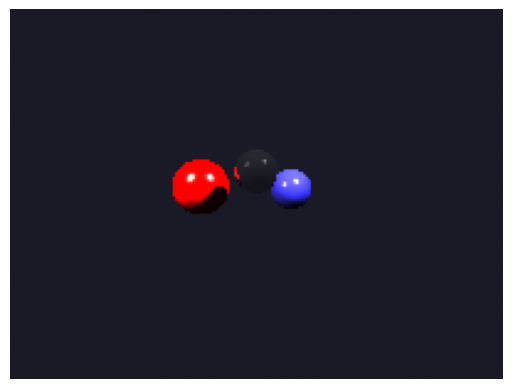

In [60]:
renderer = Renderer(max_depth=5)
img6 = renderer.render_step6(scene2, 200, 150)
img6.save_ppm("scene_with_shadow.ppm")
print("saved scene_with_shadow.ppm")
img = read_ppm_p3("scene_with_shadow.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()

### finally rendering the whole scene

saved final_scene_with_mirror_and_alaising.ppm


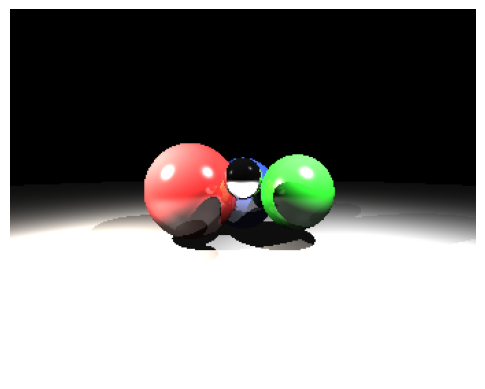

In [61]:
# I have created a new Scene object so I start clean.
final_scene = Scene()
# I choose a slightly dark background.
final_scene.bg = Color(0, 0, 0)

# I am creating the camera using the parameters from the lab manual:
# here C = camera position, P = point looked at, up = up direction, alpha/beta = view plane scale, zmin = distance to plane.
final_camera = Camera(
    # I need to put camera a bit above and back so it sees the spheres.
    C=Vec3(0.0, 0.8, 3.5),  
    # I look toward the center area.
    P=Vec3(0.0, 0.4, 0.0),   
    # to keep Y as up.
    up=Vec3(0.0, 1.0, 0.0),  
    # I set width of view plane bigger means wider view.
    alpha=1.2,          
    # here I set height of view plane.
    beta=0.9,        
    # now I set image plane distance.
    zmin=1.0                    
)

# now I need to put the camera in the scene.
final_scene.set_camera(final_camera)

# now I'm creating materials

# In the lab I have materials 
# kd is diffuse, ks is specular, shininess, ambient and reflectivity

# I make a red material.
mat_red = UniformTexture(
    kd=Color(0.9, 0.2, 0.2),
    ks=Color(0.9, 0.9, 0.9),
    shininess=50,
    reflectivity=0.15,
    ambient=0.06
)

# I make a green material.
mat_green = UniformTexture(
    kd=Color(0.2, 0.9, 0.2),
    ks=Color(0.7, 0.7, 0.7),
    shininess=30,
    reflectivity=0.10,
    ambient=0.06
)

# I make a blue material.
mat_blue = UniformTexture(
    kd=Color(0.2, 0.3, 0.9),
    ks=Color(0.9, 0.9, 0.9),
    shininess=80,
    reflectivity=0.25,
    ambient=0.06
)

# I make a mirror material.
mat_mirror = UniformTexture(
    kd=Color(0.1, 0.1, 0.1),
    ks=Color(1.0, 1.0, 1.0),
    shininess=120,
    reflectivity=0.75,
    ambient=0.02
)

# I make a floor material.
mat_floor = UniformTexture(
    kd=Color(0.8, 0.8, 0.8),
    ks=Color(0.2, 0.2, 0.2),
    shininess=10,
    reflectivity=0.05,
    ambient=0.07
)


# here now I have to add objects in the scene
# I add a red sphere on the left.
final_scene.add_object(Sphere(Vec3(-0.9, 0.45, 0.0), 0.8, mat_red))
# I add a blue sphere in the middle slightly back.
final_scene.add_object(Sphere(Vec3(0.0, 0.35, -0.6), 0.7, mat_blue))
# I add a green sphere on the right.
final_scene.add_object(Sphere(Vec3(0.9, 0.45, 0.2), 0.6, mat_green))

# I add a big floor sphere like a ground plane.
# I put it very low with huge radius so it looks like a plane.
final_scene.add_object(Sphere(Vec3(0.0, -999.0, 0.0), 998.6, mat_floor))

# I add a small mirror sphere so reflection is obvious.
final_scene.add_object(Sphere(Vec3(0.0, 0.7, 1.0), 0.25, mat_mirror))


# now I have to add lights
# I add a strong white light above right.
final_scene.add_light(PointLight(Vec3(2.0, 3.5, 2.0), Color(1.0, 1.0, 1.0), intensity=30.0))
# I added another warm light above left.
final_scene.add_light(PointLight(Vec3(-2.5, 2.0, 1.5), Color(1.0, 0.95, 0.9), intensity=18.0))

# now I am rendering the scene
# I choose final image size 
W = 340
H = 270
# I create the renderer for shadows and reflection with some recursion depth.
final_renderer = Renderer(max_depth=5)
# I render the final image.
final_img = final_renderer.render_step6(final_scene, W, H)
# 2 means 4 rays per pixel
#SAMPLES = 2   
#final_img = final_renderer.render_step6_antialias(final_scene, W, H, SAMPLES)



# save and visualizing the final scene
final_img.save_ppm("final_scene_with_mirror_and_alaising.ppm")

# I print a message so I know it worked.
print("saved final_scene_with_mirror_and_alaising.ppm")



img = read_ppm_p3("final_scene_with_mirror_and_alaising.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()



### final scene with alaising, not smooth

saved final_scene_with_alaising.ppm


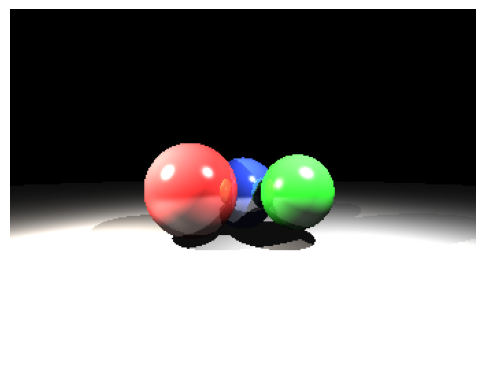

In [68]:
# I have created a new Scene object so I start clean.
final_scene = Scene()
# I choose a slightly dark background.
final_scene.bg = Color(0, 0, 0)

# I am creating the camera using the parameters from the lab manual:
# here C = camera position, P = point looked at, up = up direction, alpha/beta = view plane scale, zmin = distance to plane.
final_camera = Camera(
    # I need to put camera a bit above and back so it sees the spheres.
    C=Vec3(0.0, 0.8, 3.5),  
    # I look toward the center area.
    P=Vec3(0.0, 0.4, 0.0),   
    # to keep Y as up.
    up=Vec3(0.0, 1.0, 0.0),  
    # I set width of view plane bigger means wider view.
    alpha=1.2,          
    # here I set height of view plane.
    beta=0.9,        
    # now I set image plane distance.
    zmin=1.0                    
)

# now I need to put the camera in the scene.
final_scene.set_camera(final_camera)

# now I'm creating materials

# In the lab I have materials 
# kd is diffuse, ks is specular, shininess, ambient and reflectivity

# I make a red material.
mat_red = UniformTexture(
    kd=Color(0.9, 0.2, 0.2),
    ks=Color(0.9, 0.9, 0.9),
    shininess=50,
    reflectivity=0.15,
    ambient=0.06
)

# I make a green material.
mat_green = UniformTexture(
    kd=Color(0.2, 0.9, 0.2),
    ks=Color(0.7, 0.7, 0.7),
    shininess=30,
    reflectivity=0.10,
    ambient=0.06
)

# I make a blue material.
mat_blue = UniformTexture(
    kd=Color(0.2, 0.3, 0.9),
    ks=Color(0.9, 0.9, 0.9),
    shininess=80,
    reflectivity=0.25,
    ambient=0.06
)

# I make a mirror material.
# mat_mirror = UniformTexture(
#     kd=Color(0.1, 0.1, 0.1),
#     ks=Color(1.0, 1.0, 1.0),
#     shininess=120,
#     reflectivity=0.75,
#     ambient=0.02
# )

# I make a floor material.
mat_floor = UniformTexture(
    kd=Color(0.8, 0.8, 0.8),
    ks=Color(0.2, 0.2, 0.2),
    shininess=10,
    reflectivity=0.05,
    ambient=0.07
)


# here now I have to add objects in the scene
# I add a red sphere on the left.
final_scene.add_object(Sphere(Vec3(-0.9, 0.45, 0.0), 0.8, mat_red))
# I add a blue sphere in the middle slightly back.
final_scene.add_object(Sphere(Vec3(0.0, 0.35, -0.6), 0.7, mat_blue))
# I add a green sphere on the right.
final_scene.add_object(Sphere(Vec3(0.9, 0.45, 0.2), 0.6, mat_green))

# I add a big floor sphere like a ground plane.
# I put it very low with huge radius so it looks like a plane.
final_scene.add_object(Sphere(Vec3(0.0, -999.0, 0.0), 998.6, mat_floor))

# I add a small mirror sphere so reflection is obvious.
#final_scene.add_object(Sphere(Vec3(0.0, 0.7, 1.0), 0.25, mat_mirror))


# now I have to add lights
# I add a strong white light above right.
final_scene.add_light(PointLight(Vec3(2.0, 3.5, 2.0), Color(1.0, 1.0, 1.0), intensity=30.0))
# I added another warm light above left.
final_scene.add_light(PointLight(Vec3(-2.5, 2.0, 1.5), Color(1.0, 0.95, 0.9), intensity=18.0))

# now I am rendering the scene
# I choose final image size 
W = 340
H = 270
# I create the renderer for shadows and reflection with some recursion depth.
final_renderer = Renderer(max_depth=5)
# I render the final image.
final_img = final_renderer.render_step6(final_scene, W, H)


# save and visualizing the final scene
final_img.save_ppm("final_scene_with_alaising.ppm")

# I print a message so I know it worked.
print("saved final_scene_with_alaising.ppm")
img = read_ppm_p3("final_scene_with_alaising.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()



### final scene with anti_alaising

saved final_scene_with_anti_alaising.ppm


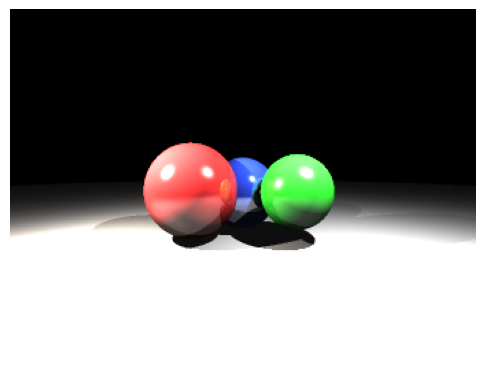

In [64]:
# I have created a new Scene object so I start clean.
final_scene = Scene()
# I choose a slightly dark background.
final_scene.bg = Color(0, 0, 0)

# I am creating the camera using the parameters from the lab manual:
# here C = camera position, P = point looked at, up = up direction, alpha/beta = view plane scale, zmin = distance to plane.
final_camera = Camera(
    # I need to put camera a bit above and back so it sees the spheres.
    C=Vec3(0.0, 0.8, 3.5),  
    # I look toward the center area.
    P=Vec3(0.0, 0.4, 0.0),   
    # to keep Y as up.
    up=Vec3(0.0, 1.0, 0.0),  
    # I set width of view plane bigger means wider view.
    alpha=1.2,          
    # here I set height of view plane.
    beta=0.9,        
    # now I set image plane distance.
    zmin=1.0                    
)

# now I need to put the camera in the scene.
final_scene.set_camera(final_camera)

# now I'm creating materials

# In the lab I have materials 
# kd is diffuse, ks is specular, shininess, ambient and reflectivity

# I make a red material.
mat_red = UniformTexture(
    kd=Color(0.9, 0.2, 0.2),
    ks=Color(0.9, 0.9, 0.9),
    shininess=50,
    reflectivity=0.15,
    ambient=0.06
)

# I make a green material.
mat_green = UniformTexture(
    kd=Color(0.2, 0.9, 0.2),
    ks=Color(0.7, 0.7, 0.7),
    shininess=30,
    reflectivity=0.10,
    ambient=0.06
)

# I make a blue material.
mat_blue = UniformTexture(
    kd=Color(0.2, 0.3, 0.9),
    ks=Color(0.9, 0.9, 0.9),
    shininess=80,
    reflectivity=0.25,
    ambient=0.06
)

# I make a mirror material.
# mat_mirror = UniformTexture(
#     kd=Color(0.1, 0.1, 0.1),
#     ks=Color(1.0, 1.0, 1.0),
#     shininess=120,
#     reflectivity=0.75,
#     ambient=0.02
# )

# I make a floor material.
mat_floor = UniformTexture(
    kd=Color(0.8, 0.8, 0.8),
    ks=Color(0.2, 0.2, 0.2),
    shininess=10,
    reflectivity=0.05,
    ambient=0.07
)


# here now I have to add objects in the scene
# I add a red sphere on the left.
final_scene.add_object(Sphere(Vec3(-0.9, 0.45, 0.0), 0.8, mat_red))
# I add a blue sphere in the middle slightly back.
final_scene.add_object(Sphere(Vec3(0.0, 0.35, -0.6), 0.7, mat_blue))
# I add a green sphere on the right.
final_scene.add_object(Sphere(Vec3(0.9, 0.45, 0.2), 0.6, mat_green))

# I add a big floor sphere like a ground plane.
# I put it very low with huge radius so it looks like a plane.
final_scene.add_object(Sphere(Vec3(0.0, -999.0, 0.0), 998.6, mat_floor))

# I add a small mirror sphere so reflection is obvious.
#final_scene.add_object(Sphere(Vec3(0.0, 0.7, 1.0), 0.25, mat_mirror))


# now I have to add lights
# I add a strong white light above right.
final_scene.add_light(PointLight(Vec3(2.0, 3.5, 2.0), Color(1.0, 1.0, 1.0), intensity=30.0))
# I added another warm light above left.
final_scene.add_light(PointLight(Vec3(-2.5, 2.0, 1.5), Color(1.0, 0.95, 0.9), intensity=18.0))

# now I am rendering the scene
# I choose final image size 
W = 340
H = 270
# I create the renderer for shadows and reflection with some recursion depth.
final_renderer = Renderer(max_depth=5)
# I render the final image.
#final_img = final_renderer.render_step6(final_scene, W, H)
# 2 means 4 rays per pixel
SAMPLES = 2   
final_img = final_renderer.render_step6_antialias(final_scene, W, H, SAMPLES)

# save and visualizing the final scene
final_img.save_ppm("final_scene_with_anti_alaising.ppm")

# I print a message so I know it worked.
print("saved final_scene_with_anti_alaising.ppm")



img = read_ppm_p3("final_scene_with_anti_alaising.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()



### final result

saved final_scene.ppm


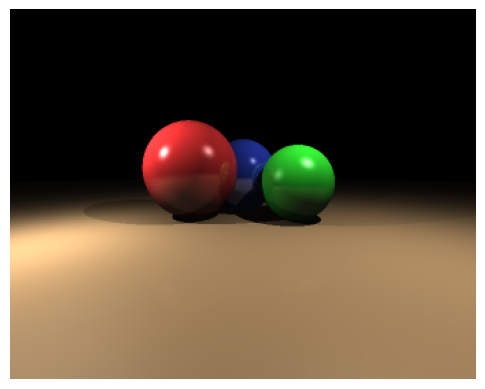

In [69]:
#final better scene with position better object correction and warm light
#I have also tried different position and different colour backgroung, plane and lighting, then I just kept this as final 
# merging all

final_scene = Scene()
final_scene.bg = Color(0, 0, 0)

final_camera = Camera(
    C=Vec3(0.0, 0.8, 3.5),      
    P=Vec3(0.0, 0.4, 0.0),      
    up=Vec3(0.0, 1.0, 0.0),     
    alpha=1.2,                  
    beta=0.9,                   
    zmin=1.0                    
)

final_scene.set_camera(final_camera)
mat_red = UniformTexture(
    kd=Color(0.9, 0.2, 0.2),
    ks=Color(0.9, 0.9, 0.9),
    shininess=50,
    reflectivity=0.15,
    ambient=0.06
)

mat_green = UniformTexture(
    kd=Color(0.2, 0.9, 0.2),
    ks=Color(0.7, 0.7, 0.7),
    shininess=30,
    reflectivity=0.10,
    ambient=0.06
)

mat_blue = UniformTexture(
    kd=Color(0.2, 0.3, 0.9),
    ks=Color(0.9, 0.9, 0.9),
    shininess=80,
    reflectivity=0.25,
    ambient=0.06
)

mat_floor = UniformTexture(
    kd=Color(0.75, 0.60, 0.42),   
    ks=Color(0.15, 0.15, 0.15),  
    shininess=10,               
    reflectivity=0.01,
    ambient=0.03
)


final_scene.add_object(Sphere(Vec3(-0.9, 0.8, 0.0), 0.8, mat_red))
final_scene.add_object(Sphere(Vec3(0.0, 0.7, -0.6), 0.7, mat_blue))
final_scene.add_object(Sphere(Vec3(0.9, 0.6, 0.2), 0.6, mat_green))
final_scene.add_object(Sphere(Vec3(0.0, -1000.0, 0.0), 1000.0, mat_floor))
final_scene.add_light(PointLight(Vec3(2.0, 3.5, 2.0), Color(1.0, 1.0, 1.0), intensity=10.0))
final_scene.add_light(PointLight(Vec3(-2.5, 2.0, 1.5), Color(1.0, 1.0, 1.0), intensity=5.0))

W = 340
H = 270
final_renderer = Renderer(max_depth=5)
SAMPLES = 2  
final_img = final_renderer.render_step6_antialias(final_scene, W, H, SAMPLES)
final_img.save_ppm("final_scene.ppm")
print("saved final_scene.ppm")
img = read_ppm_p3("final_scene.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()



### I have used SAMPLES, it means rays per pixel. the bigger this value the more smooth the final scene is.  
#### it 2^n for example i used earlier 2 means 4 rays per pixel

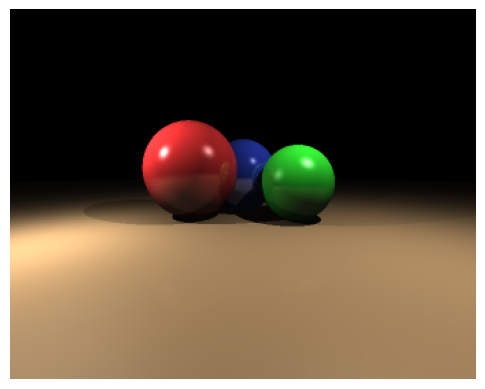

In [70]:
img = read_ppm_p3("final_scene.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()

saved final_scene_with_mirror_and_anti_alaising.ppm


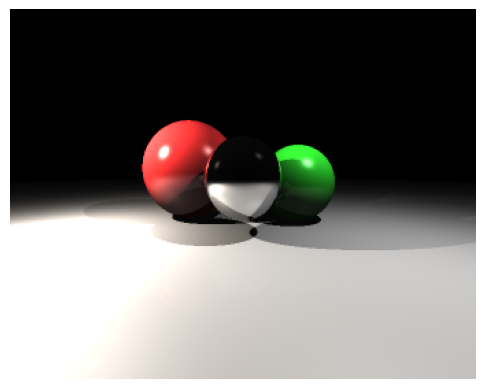

In [79]:
# I have created a new Scene object so I start clean.
final_scene = Scene()
# I choose a slightly dark background.
final_scene.bg = Color(0, 0, 0)

# I am creating the camera using the parameters from the lab manual:
# here C = camera position, P = point looked at, up = up direction, alpha/beta = view plane scale, zmin = distance to plane.
final_camera = Camera(
    # I need to put camera a bit above and back so it sees the spheres.
    C=Vec3(0.0, 0.8, 3.5),  
    # I look toward the center area.
    P=Vec3(0.0, 0.4, 0.0),   
    # to keep Y as up.
    up=Vec3(0.0, 1.0, 0.0),  
    # I set width of view plane bigger means wider view.
    alpha=1.2,          
    # here I set height of view plane.
    beta=0.9,        
    # now I set image plane distance.
    zmin=1.0                    
)

# now I need to put the camera in the scene.
final_scene.set_camera(final_camera)

# now I'm creating materials

# In the lab I have materials 
# kd is diffuse, ks is specular, shininess, ambient and reflectivity

# I make a red material.
mat_red = UniformTexture(
    kd=Color(0.9, 0.2, 0.2),
    ks=Color(0.9, 0.9, 0.9),
    shininess=50,
    reflectivity=0.15,
    ambient=0.06
)

# I make a green material.
mat_green = UniformTexture(
    kd=Color(0.2, 0.9, 0.2),
    ks=Color(0.7, 0.7, 0.7),
    shininess=30,
    reflectivity=0.10,
    ambient=0.06
)

# I make a blue material.
mat_blue = UniformTexture(
    kd=Color(0.2, 0.3, 0.9),
    ks=Color(0.9, 0.9, 0.9),
    shininess=80,
    reflectivity=0.25,
    ambient=0.06
)

# I make a mirror material.
mat_mirror = UniformTexture(
    kd=Color(0.1, 0.1, 0.1),
    ks=Color(1.0, 1.0, 1.0),
    shininess=120,
    reflectivity=0.75,
    ambient=0.02
)

# I make a floor material.
mat_floor = UniformTexture(
    kd=Color(0.8, 0.8, 0.8),
    ks=Color(0.2, 0.2, 0.2),  
    shininess=10,               
    reflectivity=0.01,
    ambient=0.03
)

final_scene.add_object(Sphere(Vec3(-0.9, 0.8, 0.0), 0.8, mat_red))
final_scene.add_object(Sphere(Vec3(0.0, 0.7, -0.6), 0.7, mat_blue))
final_scene.add_object(Sphere(Vec3(0.9, 0.6, 0.2), 0.6, mat_green))
final_scene.add_object(Sphere(Vec3(0.0, -1000.0, 0.0), 1000.0, mat_floor))

# I add a small mirror sphere so reflection is obvious.
final_scene.add_object(Sphere(Vec3(0.0, 0.7, 1.0), 0.5, mat_mirror))


# now I have to add lights
# I add a strong white light above right.
final_scene.add_light(PointLight(Vec3(2.0, 3.5, 2.0), Color(1.0, 1.0, 1.0), intensity=10.0))
# I added another warm light above left.
final_scene.add_light(PointLight(Vec3(-2.5, 2.0, 1.5), Color(1.0, 0.95, 0.9), intensity=9.0))

# now I am rendering the scene
# I choose final image size 
W = 340
H = 270
# I create the renderer for shadows and reflection with some recursion depth.
final_renderer = Renderer(max_depth=5)
# I render the final image.

SAMPLES = 2   
final_img = final_renderer.render_step6_antialias(final_scene, W, H, SAMPLES)



# save and visualizing the final scene
final_img.save_ppm("final_scene_with_mirror_and_anti_alaising.ppm")
print("saved final_scene_with_mirror_and_anti_alaising.ppm")
img = read_ppm_p3("final_scene_with_mirror_and_anti_alaising.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()



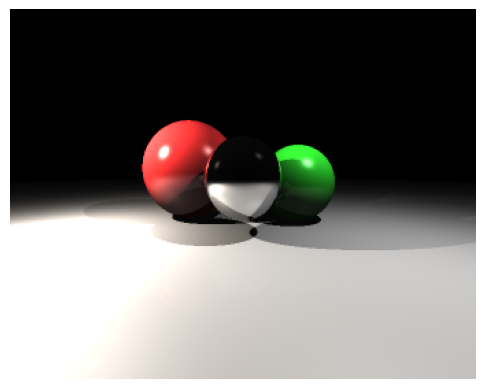

In [80]:
img = read_ppm_p3("final_scene_with_mirror_and_anti_alaising.ppm")
plt.imshow(img)
plt.axis("off")
plt.show()